In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual style for the plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [10]:
# ==========================================
# CONFIGURATION - EDIT THESE TO MATCH YOUR WAREHOUSE
# ==========================================

# The target the system expects you to hit
TARGET_PPH = 220 

# How many items fit in a container?
ITEMS_PER_SMALL_BOX = 1
ITEMS_PER_MEDIUM_BOX = 1
ITEMS_PER_TOTE = 150  # You mentioned large volumes, change this to 200 if needed

# How long does it take to handle/pick 1 item? (in seconds)
# Note: Tote items might be faster to pick per item if they are bulk, or slower if heavy.
TIME_PER_ITEM_SMALL = 15 
TIME_PER_ITEM_MEDIUM = 18
TIME_PER_ITEM_TOTE = 10 

# Handling time per container (scanning, closing, moving) in seconds
TIME_PER_CONTAINER_SMALL = 10
TIME_PER_CONTAINER_MEDIUM = 12
TIME_PER_CONTAINER_TOTE = 60 # Totes take longer to close/move/seal

print(f"Simulation Config: Target is {TARGET_PPH} Picks Per Hour.")

Simulation Config: Target is 220 Picks Per Hour.


In [11]:
# ==========================================
# 1. DEFINE THE DATA GENERATOR FUNCTION
# ==========================================
# (This tells Python how to simulate a worker's shift)

def generate_shift_data(worker_type, shift_length_hours=8):
    """
    Generates data for one worker for a full shift.
    worker_type: 'Box_Picker', 'Tote_Picker', or 'Mixed'
    """
    data = []
    
    for hour in range(shift_length_hours):
        if worker_type == 'Box_Picker':
            # This worker picks small items all day
            small = np.random.randint(80, 120)
            medium = np.random.randint(40, 60)
            totes = np.random.randint(0, 2) # Very few totes
            
        elif worker_type == 'Tote_Picker':
            # This worker picks bulk/large items all day
            small = np.random.randint(0, 10)
            medium = np.random.randint(0, 5)
            totes = np.random.randint(3, 5) # Several totes per hour
            
        elif worker_type == 'Mixed':
            # A mix of everything
            small = np.random.randint(20, 40)
            medium = np.random.randint(10, 20)
            totes = np.random.randint(1, 3)
            
        # --- CALCULATIONS ---
        
        # 1. Total Items Moved (The Truth)
        total_items = (small * ITEMS_PER_SMALL_BOX) + \
                      (medium * ITEMS_PER_MEDIUM_BOX) + \
                      (totes * ITEMS_PER_TOTE)
        
        # 2. Actual Time Spent (Physics)
        work_seconds = (small * TIME_PER_ITEM_SMALL) + (small * TIME_PER_CONTAINER_SMALL) + \
                       (medium * TIME_PER_ITEM_MEDIUM) + (medium * TIME_PER_CONTAINER_MEDIUM) + \
                       (totes * TIME_PER_ITEM_TOTE) + (totes * TIME_PER_CONTAINER_TOTE)
        
        work_minutes = work_seconds / 60.0
        
        data.append({
            'Hour': hour + 1,
            'Worker_Type': worker_type,
            'Small_Boxes': small,
            'Medium_Boxes': medium,
            'Totes': totes,
            'Total_Items_Actual': total_items,
            'Work_Minutes_Actual': work_minutes
        })
        
    return data

print("Function 'generate_shift_data' is ready to use.")

Function 'generate_shift_data' is ready to use.


In [12]:
# ==========================================
# MASS DATA SIMULATION
# ==========================================

# CONFIGURATION - How much data do you want?
NUM_WORKERS = 50        # How many employees to simulate
NUM_DAYS = 20           # How many days of history
HOURS_PER_SHIFT = 8     # Standard shift length

data_list = []

print(f"Generating data for {NUM_WORKERS} workers over {NUM_DAYS} days...")

for worker_id in range(1, NUM_WORKERS + 1):
    # Assign a random "style" to each worker (some pick boxes, some pick totes, some mixed)
    # This makes the data realistic
    style_options = ['Box_Picker', 'Tote_Picker', 'Mixed']
    worker_style = np.random.choice(style_options, p=[0.4, 0.4, 0.2]) # 40% Box, 40% Tote, 20% Mixed
    
    for day in range(1, NUM_DAYS + 1):
        
        # Generate data for each hour of the shift
        shift_data = generate_shift_data(worker_style, HOURS_PER_SHIFT)
        
        # Add identifiers to the data
        for row in shift_data:
            row['Worker_ID'] = f'EMP_{worker_id:03d}'
            row['Date'] = f'Day_{day}'
            data_list.append(row)

# Create the massive DataFrame
df = pd.DataFrame(data_list)

# --- RECALCULATE SYSTEM METRICS (Same as before) ---
df['System_Pick_Count'] = df['Small_Boxes'] + df['Medium_Boxes'] + df['Totes']
df['System_PPH'] = df['System_Pick_Count']

print("Data Generation Complete!")
print(f"Total Records Generated: {len(df)}")
print(f"Total simulated work hours: {len(df)}")

# Show a snapshot of the new data
display(df.head())

Generating data for 50 workers over 20 days...
Data Generation Complete!
Total Records Generated: 8000
Total simulated work hours: 8000


,Hour,Worker_Type,Small_Boxes,Medium_Boxes,Totes,Total_Items_Actual,Work_Minutes_Actual,Worker_ID,Date,System_Pick_Count,System_PPH
0,1,Box_Picker,90,44,1,284,60.666667,EMP_001,Day_1,135,135
1,2,Box_Picker,97,53,1,300,68.083333,EMP_001,Day_1,151,151
2,3,Box_Picker,118,47,0,165,72.666667,EMP_001,Day_1,165,165
3,4,Box_Picker,102,43,0,145,64.000000,EMP_001,Day_1,145,145
4,5,Box_Picker,97,40,1,287,61.583333,EMP_001,Day_1,138,138


/var/folders/m1/5h3ntt053xsb2cv3wfy_wx900000gn/T/ipykernel_30825/2233662792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Worker_Type', y='System_PPH', data=df, estimator=np.mean, ax=ax1, palette='Blues_d')
/var/folders/m1/5h3ntt053xsb2cv3wfy_wx900000gn/T/ipykernel_30825/2233662792.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Worker_Type', y='Total_Items_Actual', data=df, estimator=np.mean, ax=ax2, palette='Greens_d')


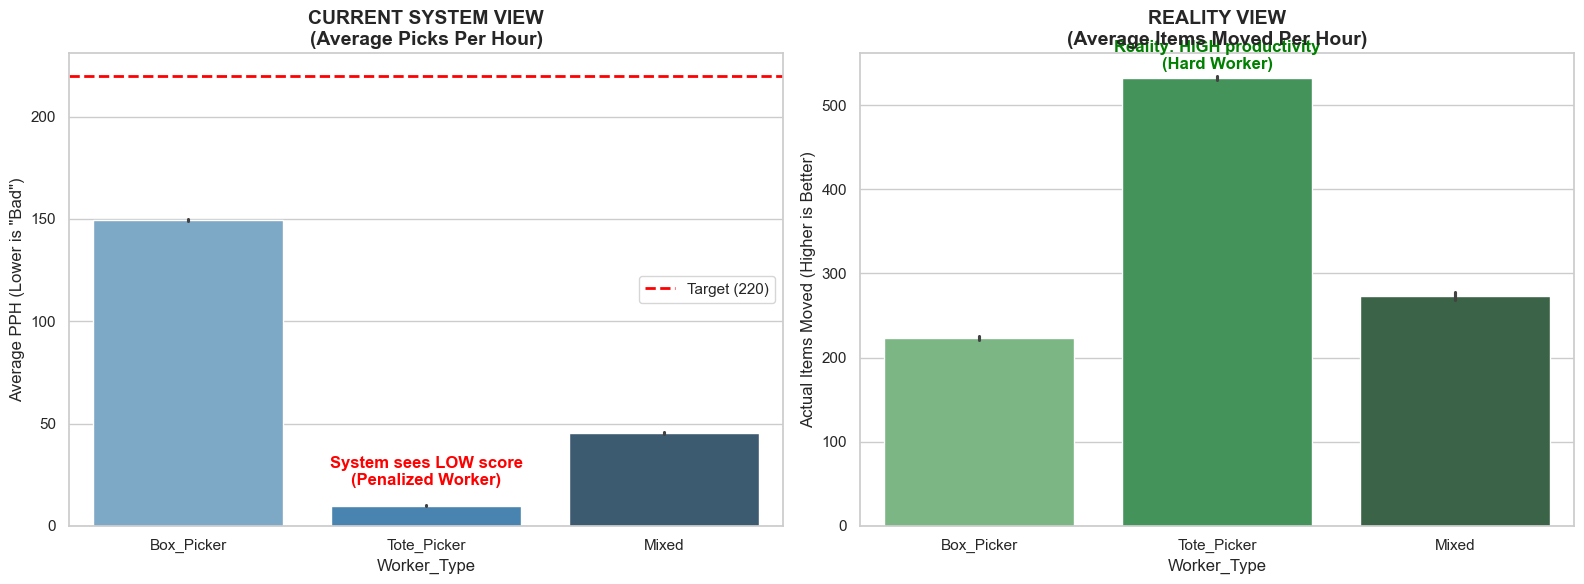

In [13]:
# ==========================================
# VISUALIZATION: THE PROBLEM
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: What the System Sees (PPH)
sns.barplot(x='Worker_Type', y='System_PPH', data=df, estimator=np.mean, ax=ax1, palette='Blues_d')
ax1.axhline(y=TARGET_PPH, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_PPH})')
ax1.set_title('CURRENT SYSTEM VIEW\n(Average Picks Per Hour)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average PPH (Lower is "Bad")')
ax1.legend()

# Add text annotation for the Tote Picker problem
avg_tote_pph = df[df['Worker_Type'] == 'Tote_Picker']['System_PPH'].mean()
ax1.text(1, avg_tote_pph + 10, "System sees LOW score\n(Penalized Worker)", 
         ha='center', color='red', fontweight='bold')

# Chart 2: What Actually Happened (Items Per Hour)
sns.barplot(x='Worker_Type', y='Total_Items_Actual', data=df, estimator=np.mean, ax=ax2, palette='Greens_d')
ax2.set_title('REALITY VIEW\n(Average Items Moved Per Hour)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual Items Moved (Higher is Better)')

# Add text annotation
ax2.text(1, df[df['Worker_Type'] == 'Tote_Picker']['Total_Items_Actual'].mean() + 10, 
         "Reality: HIGH productivity\n(Hard Worker)", 
         ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

Calculated Weights:
- Small Box: 1.0 Point
- Medium Box: 1.2 Points
- Tote: 62.4 Points (This is how many 'small picks' a tote is worth)


/var/folders/m1/5h3ntt053xsb2cv3wfy_wx900000gn/T/ipykernel_30825/1946511982.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Worker_Type', y='Fair_PPH', data=df, estimator=np.mean, palette='Purples_d')


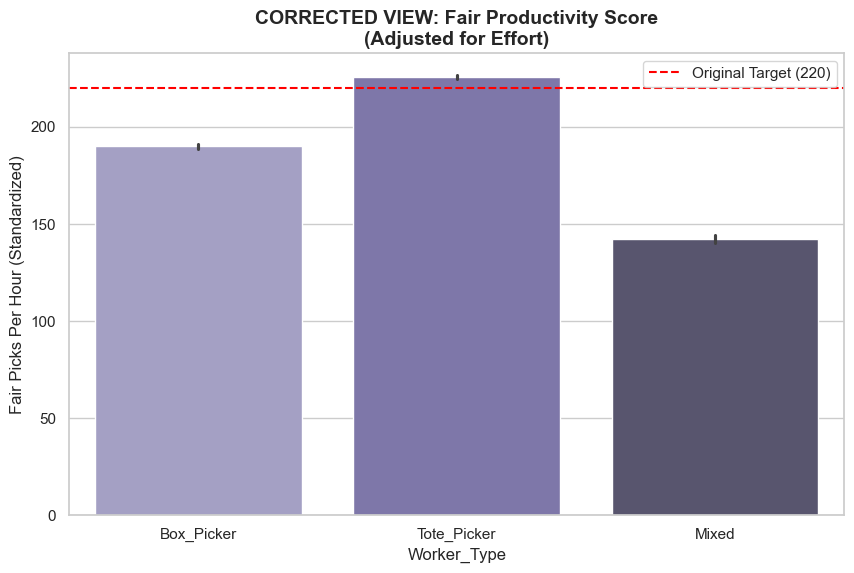


Comparison Table:
             System_PPH  Total_Items_Actual  Fair_PPH
Worker_Type                                          
Box_Picker        149.6               223.2     189.9
Mixed              45.3               273.3     142.1
Tote_Picker        10.0               532.5     225.7


In [14]:
# ==========================================
# THE FIX: WEIGHTED PRODUCTIVITY
# ==========================================

# We define "Work Points" based on the time it takes.
# If Small Box = 1 Point (Baseline)
# Tote Points = (Time to process a Tote) / (Time to process a Small Box)

# Calculate average time per container type
avg_time_small = (TIME_PER_ITEM_SMALL + TIME_PER_CONTAINER_SMALL) / 60.0
avg_time_tote = ((ITEMS_PER_TOTE * TIME_PER_ITEM_TOTE) + TIME_PER_CONTAINER_TOTE) / 60.0

tote_weight = avg_time_tote / avg_time_small
medium_weight = ((TIME_PER_ITEM_MEDIUM + TIME_PER_CONTAINER_MEDIUM) / 60.0) / avg_time_small

print(f"Calculated Weights:")
print(f"- Small Box: 1.0 Point")
print(f"- Medium Box: {medium_weight:.1f} Points")
print(f"- Tote: {tote_weight:.1f} Points (This is how many 'small picks' a tote is worth)")

# Apply the Fix
df['Fair_Score'] = (df['Small_Boxes'] * 1.0) + \
                   (df['Medium_Boxes'] * medium_weight) + \
                   (df['Totes'] * tote_weight)

df['Fair_PPH'] = df['Fair_Score'] # Since it's per hour

# ==========================================
# VISUALIZATION: THE FIX
# ==========================================
plt.figure(figsize=(10, 6))

# Plotting Fair PPH
sns.barplot(x='Worker_Type', y='Fair_PPH', data=df, estimator=np.mean, palette='Purples_d')
plt.axhline(y=TARGET_PPH, color='red', linestyle='--', label=f'Original Target ({TARGET_PPH})')

plt.title('CORRECTED VIEW: Fair Productivity Score\n(Adjusted for Effort)', fontsize=14, fontweight='bold')
plt.ylabel('Fair Picks Per Hour (Standardized)')
plt.legend()

plt.show()

print("\nComparison Table:")
print(df.groupby('Worker_Type')[['System_PPH', 'Total_Items_Actual', 'Fair_PPH']].mean().round(1))

In [15]:
# ==========================================
# SAVE DATA TO A FILE
# ==========================================

# This creates a file called 'warehouse_simulation_data.csv'
df.to_csv('warehouse_simulation_data.csv', index=False)

print("Data saved successfully!")
print("Look for a file named 'warehouse_simulation_data.csv' in your Jupyter folder.")

Data saved successfully!
Look for a file named 'warehouse_simulation_data.csv' in your Jupyter folder.


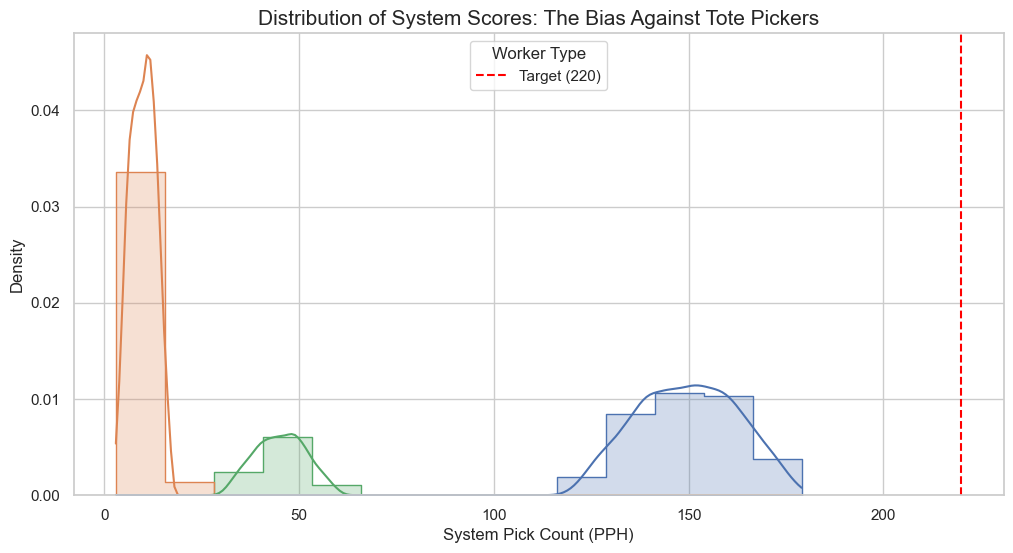

In [16]:
# VISUALIZING THE BIAS IN LARGE DATA

plt.figure(figsize=(12, 6))

# We use a histogram to see the distribution of scores
# Hue splits the data by Worker Style
sns.histplot(data=df, x='System_PPH', hue='Worker_Type', kde=True, element="step", stat="density")

plt.axvline(x=TARGET_PPH, color='red', linestyle='--', label='Target (220)')

plt.title('Distribution of System Scores: The Bias Against Tote Pickers', fontsize=15)
plt.xlabel('System Pick Count (PPH)')
plt.legend(title='Worker Type')

plt.show()

In [ ]:
# HOW TO LOAD THE DATA LATER
df = pd.read_csv('warehouse_simulation_data.csv')
print("Data loaded!")

In [ ]:
# Optional: Save as Excel
# You may need to run this first: !pip install openpyxl
df.to_excel('warehouse_simulation_data.xlsx', index=False)

In [17]:
# ==========================================
# 1. PREPARE DATA FOR MACHINE LEARNING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features: What the model sees (The Containers)
X = df[['Small_Boxes', 'Medium_Boxes', 'Totes']]

# Target: What the model tries to predict (The Effort/Time)
# We use 'Work_Minutes_Actual' as the truth for how hard the work was.
y = df['Work_Minutes_Actual']

# Split data: 80% for learning, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready for training.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Data is ready for training.
Training samples: 6400
Testing samples: 1600


In [18]:
# ==========================================
# 2. TRAIN THE MODEL
# ==========================================

# Initialize the model
model = LinearRegression()

# Train the model on the data
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [19]:
# ==========================================
# 3. SEE WHAT THE MODEL LEARNED
# ==========================================

# Get the coefficients (the "Weights")
weights = model.coef_

print("--- MACHINE LEARNING INSIGHTS ---")
print(f"Weight for Small Box: {weights[0]:.2f} minutes per box")
print(f"Weight for Medium Box: {weights[1]:.2f} minutes per box")
print(f"Weight for Tote:       {weights[2]:.2f} minutes per tote") 
print("---------------------------------")

# Compare to the old system
# The old system counts everything as "1"
print("\nComparison:")
print(f"Old System thinks a Tote is worth: 1 unit")
print(f"ML Model thinks a Tote is worth:   {weights[2]/weights[0]:.1f} units (Standard Picks)")

--- MACHINE LEARNING INSIGHTS ---
Weight for Small Box: 0.42 minutes per box
Weight for Medium Box: 0.50 minutes per box
Weight for Tote:       1.17 minutes per tote
---------------------------------

Comparison:
Old System thinks a Tote is worth: 1 unit
ML Model thinks a Tote is worth:   2.8 units (Standard Picks)


In [20]:
# ==========================================
# 4. VALIDATE ACCURACY
# ==========================================

# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate error
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Accuracy (R2 Score): {r2:.2f} (1.0 is perfect)")
print(f"Average Error: {mae:.2f} minutes per hour")

Model Accuracy (R2 Score): 1.00 (1.0 is perfect)
Average Error: 0.00 minutes per hour


--- TOP 10 WORKERS (ML Fairness Ranking) ---
Worker_ID
EMP_002    1.0
EMP_008    1.0
EMP_046    1.0
EMP_043    1.0
EMP_016    1.0
EMP_014    1.0
EMP_011    1.0
EMP_031    1.0
EMP_036    1.0
EMP_027    1.0
Name: ML_Efficiency_Score, dtype: float64


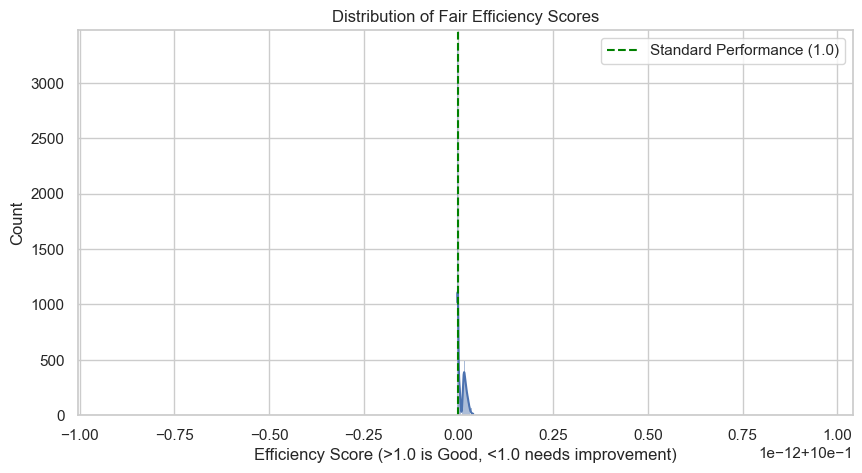

In [21]:
# ==========================================
# 5. APPLY THE FIX
# ==========================================

# Predict the "Expected Time" for every row in the dataset
df['Predicted_Work_Minutes'] = model.predict(X)

# Efficiency Score = (Predicted Time / Actual Time)
# If you did 60 mins of work in 50 mins, your score is 1.2 (Super productive!)
df['ML_Efficiency_Score'] = df['Predicted_Work_Minutes'] / df['Work_Minutes_Actual']

# Display the new Leaderboard
leaderboard = df.groupby('Worker_ID')['ML_Efficiency_Score'].mean().sort_values(ascending=False)

print("--- TOP 10 WORKERS (ML Fairness Ranking) ---")
print(leaderboard.head(10))

# Visualize the distribution of the new scores
plt.figure(figsize=(10, 5))
sns.histplot(df['ML_Efficiency_Score'], kde=True, bins=30)
plt.axvline(x=1.0, color='green', linestyle='--', label='Standard Performance (1.0)')
plt.title('Distribution of Fair Efficiency Scores')
plt.xlabel('Efficiency Score (>1.0 is Good, <1.0 needs improvement)')
plt.legend()
plt.show()